In [9]:
!pip install cmdstanpy
!pip install prophet


   ---------------------------------------- 0.0/99.1 kB ? eta -:--:--
   ------------ --------------------------- 30.7/99.1 kB ? eta -:--:--
   ---------------------------------------- 99.1/99.1 kB 1.4 MB/s eta 0:00:00
     ---------------------------------------- 0.0/53.2 kB ? eta -:--:--
     -------------------------------------- - 51.2/53.2 kB 1.3 MB/s eta 0:00:01
     -------------------------------------- 53.2/53.2 kB 914.1 kB/s eta 0:00:00
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.1/12.1 MB 3.4 MB/s eta 0:00:04
   ---------------------------------------- 0.1/12.1 MB 1.8 MB/s eta 0:00:07
    --------------------------------------- 0.3/12.1 MB 2.0 MB/s eta 0:00:07
   - -------------------------------------- 0.4/12.1 MB 2.0 MB/s eta 0:00:06
   - -------------------------------------- 0.6/12.1 MB 2.5 MB/s eta 0:00:05
   -- ------------------------------------- 0.9/12.1 MB 3.1 MB/s eta 0:00:04
   ---- ---------

In [11]:
import pandas as pd
import re
from prophet import Prophet
from prophet.plot import plot_seasonality

## Experiment parameter

In [14]:
PRIOR = 0.03

## Reading data

Read processed table excel file

In [18]:
tng_dust_table  = pd.read_excel('manual_table_filtering.xlsx',sheet_name=-1)
tng_dust_table.drop('Index',axis=1,inplace=True)
tng_dust_table

,Date,type,change,comments,influence on rate,keep
0,10.-19.05.2014,HW,Mirror-Alignment,https://www.fact-project.org/logbook/showthre...,positive step,Yes (mirror)
1,,,Change from Davis-Cotton to Davis-Cotton-Para...,,(improvement in timing -> better background s...,No (no date)
2,,,New Pointing Model,,(related to mirror alignment),No (no date)
3,20.05.2014,HW,"Camera repair, Replacement of Capacitors",https://www.fact-project.org/logbook/showthre...,,No (unsure of the effect)
4,21.05.2014,HW,"Allskcam, Fact Weatherstation",,not relevant,No
5,24.5.2014,SW,new QLA,"new calibration, old cleaning with new levels...",only relevant if QLA used - then a step is ex...,No (unsure of the effect)
6,29.6.-1.7.2014,AT,high TNGDust,,,Yes (dust)
7,15.7.-16.7.2014,AT,high TNGDust,,,Yes (dust)
8,17.8.-2.9.2014,AT,very high TNGDust,,,Yes (dust)
9,21.10.-26.10.2014,AT,high TNGDust,,,Yes (dust)


In [20]:
tng_dust_table.keep.unique()

array(['Yes (mirror)', 'No (no date)', 'No (unsure of the effect)', 'No',
       'Yes (dust)', 'No, but dig deeper'], dtype=object)

In [22]:
event_filter = ['Yes (mirror)','Yes (dust)']
tng_dust_table = tng_dust_table.loc[tng_dust_table.keep.isin(event_filter)]

Peek into the effects of kept rows

In [25]:
tng_dust_table.change.unique()

array([' Mirror-Alignment ', ' high TNGDust ', ' very high TNGDust ',
       ' mirror alignment eSCCAN method ', ' mirror re-aligned ',
       ' misaligned mirror taken off ', ' put mirror back  ',
       ' aligned mirror  '], dtype=object)

Filter for events, any matches will be added

In [28]:
# clean code, docstrings, in english

# Define keywords for each event type, dust: tng dust, mirror: anything but dust 
dust_pattern = 'TNGDust'

# Create masks to filter the original table
dust_mask = tng_dust_table['change'].str.contains(dust_pattern, case=False, na=False)
mirror_mask = ~tng_dust_table['change'].str.contains(dust_pattern, case=False, na=False)

# Create separate dataframes for each event type
dust_events_df = tng_dust_table[dust_mask].copy()
mirror_events_df = tng_dust_table[mirror_mask].copy()

Event list to consider

In [31]:
dust_events_df

,Date,type,change,comments,influence on rate,keep
6,29.6.-1.7.2014,AT,high TNGDust,,,Yes (dust)
7,15.7.-16.7.2014,AT,high TNGDust,,,Yes (dust)
8,17.8.-2.9.2014,AT,very high TNGDust,,,Yes (dust)
9,21.10.-26.10.2014,AT,high TNGDust,,,Yes (dust)
10,10.1.-13.1.2015,AT,very high TNGDust,,,Yes (dust)
11,7.3.-12.3.2015,AT,high TNGDust,,,Yes (dust)
12,10.5.-19.5.2015,AT,high TNGDust,,,Yes (dust)
17,4.6.-6.6.2015,AT,high TNGDust,,,Yes (dust)
18,6.7.-24.7.2015,AT,very high TNGDust,,,Yes (dust)
21,7.8.-21.8.2015,AT,high TNGDust,,,Yes (dust)


In [33]:
mirror_events_df

,Date,type,change,comments,influence on rate,keep
0,10.-19.05.2014,HW,Mirror-Alignment,https://www.fact-project.org/logbook/showthre...,positive step,Yes (mirror)
14,May 2015,HW,mirror alignment eSCCAN method,somewhen between 21. and 28.5. https://www.fa...,positive step if there was a mirror alignment...,Yes (mirror)
29,1.9.2016,HW,mirror re-aligned,https://www.fact-project.org/logbook/showthre...,small positive step (mostly 2 mirrors aligned...,Yes (mirror)
36,3.3.2017,HW,misaligned mirror taken off,s fact-online,negative step (1/30),Yes (mirror)
38,3.4.2017,HW,put mirror back,https://www.fact-project.org/logbook/showthre...,some positive step,Yes (mirror)
39,7.4.2017,HW,aligned mirror,https://www.fact-project.org/logbook/showthre...,rest of positive step expected,Yes (mirror)


## Fix date parsing from file 
Short term solution, ideally we should standardize a format 

In [36]:
import re
import calendar
from dateutil import parser
import pandas as pd

def parse_date_range(raw: str) -> tuple[str, str]:
    """
    Parses mixed-format dates into (start_date, end_date) in dd-mm-yyyy format.

    Possible formats:
      - 26.6.-28.6.2012          (range within the same year)
      - 10.-19.05.2014           (range within the same month) <-- ADDED
      - 23.12.2016-8.1.2017      (range crossing years)
      - 25.1.2013                 (single date)
      - May 2015                  (month-year)

    Args:
        raw (str): Raw date string.

    Returns:
        tuple[str, str]: (start_date, end_date) in dd-mm-yyyy format.
                         Returns (None, None) if format not recognized.
    """
    raw = raw.strip()

    # Case: range within the same year, e.g., 26.6.-28.6.2012
    # Added $ anchor for a full string match
    match = re.match(r'(\d{1,2})\.(\d{1,2})\.-(\d{1,2})\.(\d{1,2})\.(\d{4})$', raw)
    if match:
        d1, m1, d2, m2, y = map(int, match.groups())
        start = f"{d1:02d}-{m1:02d}-{y}"
        end = f"{d2:02d}-{m2:02d}-{y}"
        return start, end

    # --- START OF MODIFICATION ---
    # Case: range within the same month, e.g., 10.-19.05.2014
    match = re.match(r'(\d{1,2})\.-(\d{1,2})\.(\d{1,2})\.(\d{4})$', raw)
    if match:
        d1, d2, m, y = map(int, match.groups())
        start = f"{d1:02d}-{m:02d}-{y}"
        end = f"{d2:02d}-{m:02d}-{y}"
        return start, end
    # --- END OF MODIFICATION ---

    # Case: range crossing years, e.g., 23.12.2016-8.1.2017
    # Added $ anchor
    match = re.match(r'(\d{1,2})\.(\d{1,2})\.(\d{4})-(\d{1,2})\.(\d{1,2})\.(\d{4})$', raw)
    if match:
        d1, m1, y1, d2, m2, y2 = map(int, match.groups())
        start = f"{d1:02d}-{m1:02d}-{y1}"
        end = f"{d2:02d}-{m2:02d}-{y2}"
        return start, end

    # Case: single German-style date, e.g., 25.1.2013
    match = re.match(r'(\d{1,2})\.(\d{1,2})\.(\d{4})$', raw)
    if match:
        d, m, y = map(int, match.groups())
        date = f"{d:02d}-{m:02d}-{y}"
        return date, date

    # Case: month-year text, e.g., May 2015
    match = re.match(r'([A-Za-z]+)\s+(\d{4})$', raw)
    if match:
        month_name, y = match.groups()
        y = int(y)
        # start = 1st day, end = last day of month
        m = parser.parse(month_name).month
        last_day = calendar.monthrange(y, m)[1]
        start = f"01-{m:02d}-{y}"
        end = f"{last_day:02d}-{m:02d}-{y}"
        return start, end

    # If no pattern matches, return None
    return None, None



In [38]:
# clean code, docstrings, in english

def apply_date_parsing(df: pd.DataFrame) -> pd.DataFrame:
    """
    Applies the date parsing function to the 'Date' column and returns a 
    clean dataframe with 'start_date' and 'end_date'.
    """
    # Apply the parsing function to create start and end date columns
    date_ranges = df["Date"].apply(lambda x: pd.Series(parse_date_range(x)))
    df[["start_date", "end_date"]] = date_ranges
    
    # Convert columns to datetime objects
    df['start_date'] = pd.to_datetime(df['start_date'], format='%d-%m-%Y')
    df['end_date'] = pd.to_datetime(df['end_date'], format='%d-%m-%Y')

    # Drop the original 'Date' column
    return df.drop('Date', axis=1)

# Process both dataframes
dust_events_df = apply_date_parsing(dust_events_df)
mirror_events_df = apply_date_parsing(mirror_events_df)

In [40]:
mirror_events_df

,type,change,comments,influence on rate,keep,start_date,end_date
0,HW,Mirror-Alignment,https://www.fact-project.org/logbook/showthre...,positive step,Yes (mirror),2014-05-10,2014-05-19
14,HW,mirror alignment eSCCAN method,somewhen between 21. and 28.5. https://www.fa...,positive step if there was a mirror alignment...,Yes (mirror),2015-05-01,2015-05-31
29,HW,mirror re-aligned,https://www.fact-project.org/logbook/showthre...,small positive step (mostly 2 mirrors aligned...,Yes (mirror),2016-09-01,2016-09-01
36,HW,misaligned mirror taken off,s fact-online,negative step (1/30),Yes (mirror),2017-03-03,2017-03-03
38,HW,put mirror back,https://www.fact-project.org/logbook/showthre...,some positive step,Yes (mirror),2017-04-03,2017-04-03
39,HW,aligned mirror,https://www.fact-project.org/logbook/showthre...,rest of positive step expected,Yes (mirror),2017-04-07,2017-04-07


In [42]:
# clean code, docstrings, in english

# 1. Create the holidays dataframe for TNGDust events
dust_events_df['upper_window'] = (dust_events_df['end_date'] - dust_events_df['start_date']).dt.days
holidays = pd.DataFrame({
    'holiday': 'TNGDust',  # Use a consistent name for the event
    'ds': dust_events_df['start_date'],
    'lower_window': 0,
    'upper_window': dust_events_df['upper_window'],
})

# 2. Create the changepoints list from mirror alignment events
# Prophet uses the start date of the event as the changepoint
changepoints = mirror_events_df['start_date'].tolist()

print(f"Created {len(holidays)} holiday events (dust).")
print(f"Created {len(changepoints)} changepoint events (mirror alignment).")

Created 23 holiday events (dust).
Created 6 changepoint events (mirror alignment).


In [44]:
mirror_events_df

,type,change,comments,influence on rate,keep,start_date,end_date
0,HW,Mirror-Alignment,https://www.fact-project.org/logbook/showthre...,positive step,Yes (mirror),2014-05-10,2014-05-19
14,HW,mirror alignment eSCCAN method,somewhen between 21. and 28.5. https://www.fa...,positive step if there was a mirror alignment...,Yes (mirror),2015-05-01,2015-05-31
29,HW,mirror re-aligned,https://www.fact-project.org/logbook/showthre...,small positive step (mostly 2 mirrors aligned...,Yes (mirror),2016-09-01,2016-09-01
36,HW,misaligned mirror taken off,s fact-online,negative step (1/30),Yes (mirror),2017-03-03,2017-03-03
38,HW,put mirror back,https://www.fact-project.org/logbook/showthre...,some positive step,Yes (mirror),2017-04-03,2017-04-03
39,HW,aligned mirror,https://www.fact-project.org/logbook/showthre...,rest of positive step expected,Yes (mirror),2017-04-07,2017-04-07


In [46]:
changepoints


[Timestamp('2014-05-10 00:00:00'),
 Timestamp('2015-05-01 00:00:00'),
 Timestamp('2016-09-01 00:00:00'),
 Timestamp('2017-03-03 00:00:00'),
 Timestamp('2017-04-03 00:00:00'),
 Timestamp('2017-04-07 00:00:00')]

In [48]:
holidays

,holiday,ds,lower_window,upper_window
6,TNGDust,2014-06-29,0,2
7,TNGDust,2014-07-15,0,1
8,TNGDust,2014-08-17,0,16
9,TNGDust,2014-10-21,0,5
10,TNGDust,2015-01-10,0,3
11,TNGDust,2015-03-07,0,5
12,TNGDust,2015-05-10,0,9
17,TNGDust,2015-06-04,0,2
18,TNGDust,2015-07-06,0,18
21,TNGDust,2015-08-07,0,14


In [59]:
df = pd.read_csv('SQL_avgfR750Cor_vs_night_allS.txt',sep='\t')

In [63]:
df.columns

Index(['x', 'y', 'ontime', 'e', 's', 'err_y', 'start', 'stop', 'zdmin',
       'zdmax', 'azmin', 'azmax', 'thmin', 'thmax'],
      dtype='object')

In [65]:
df = df[['x','y','err_y']]

In [67]:
df.columns = ['ds','y','err_y']
df

,ds,y,err_y
0,2019-02-03,252.938334,7.773540
1,2012-05-22,260.355217,6.283639
2,2012-05-25,261.963600,7.732978
3,2012-05-27,263.931315,9.587087
4,2012-05-28,259.388334,6.737749
...,...,...,...
1611,2016-10-22,250.022501,7.111910
1612,2017-10-27,209.966249,5.054516
1613,2015-07-19,253.195335,7.435817
1614,2016-02-27,250.468887,9.734059


In [69]:
df = df.sort_values(by='ds').reset_index(drop=True)

In [71]:
df['ds'] =pd.to_datetime(df['ds'])

In [73]:
df

,ds,y,err_y
0,2012-05-08,280.310905,23.023699
1,2012-05-09,253.073335,3.481213
2,2012-05-18,255.731843,7.661158
3,2012-05-21,252.802352,5.454455
4,2012-05-22,260.355217,6.283639
...,...,...,...
1611,2019-10-06,228.672222,9.274353
1612,2019-10-07,226.110355,7.751010
1613,2019-10-08,229.159018,10.413196
1614,2019-10-09,228.963171,9.433372


## Data review
Quick plot to check data 

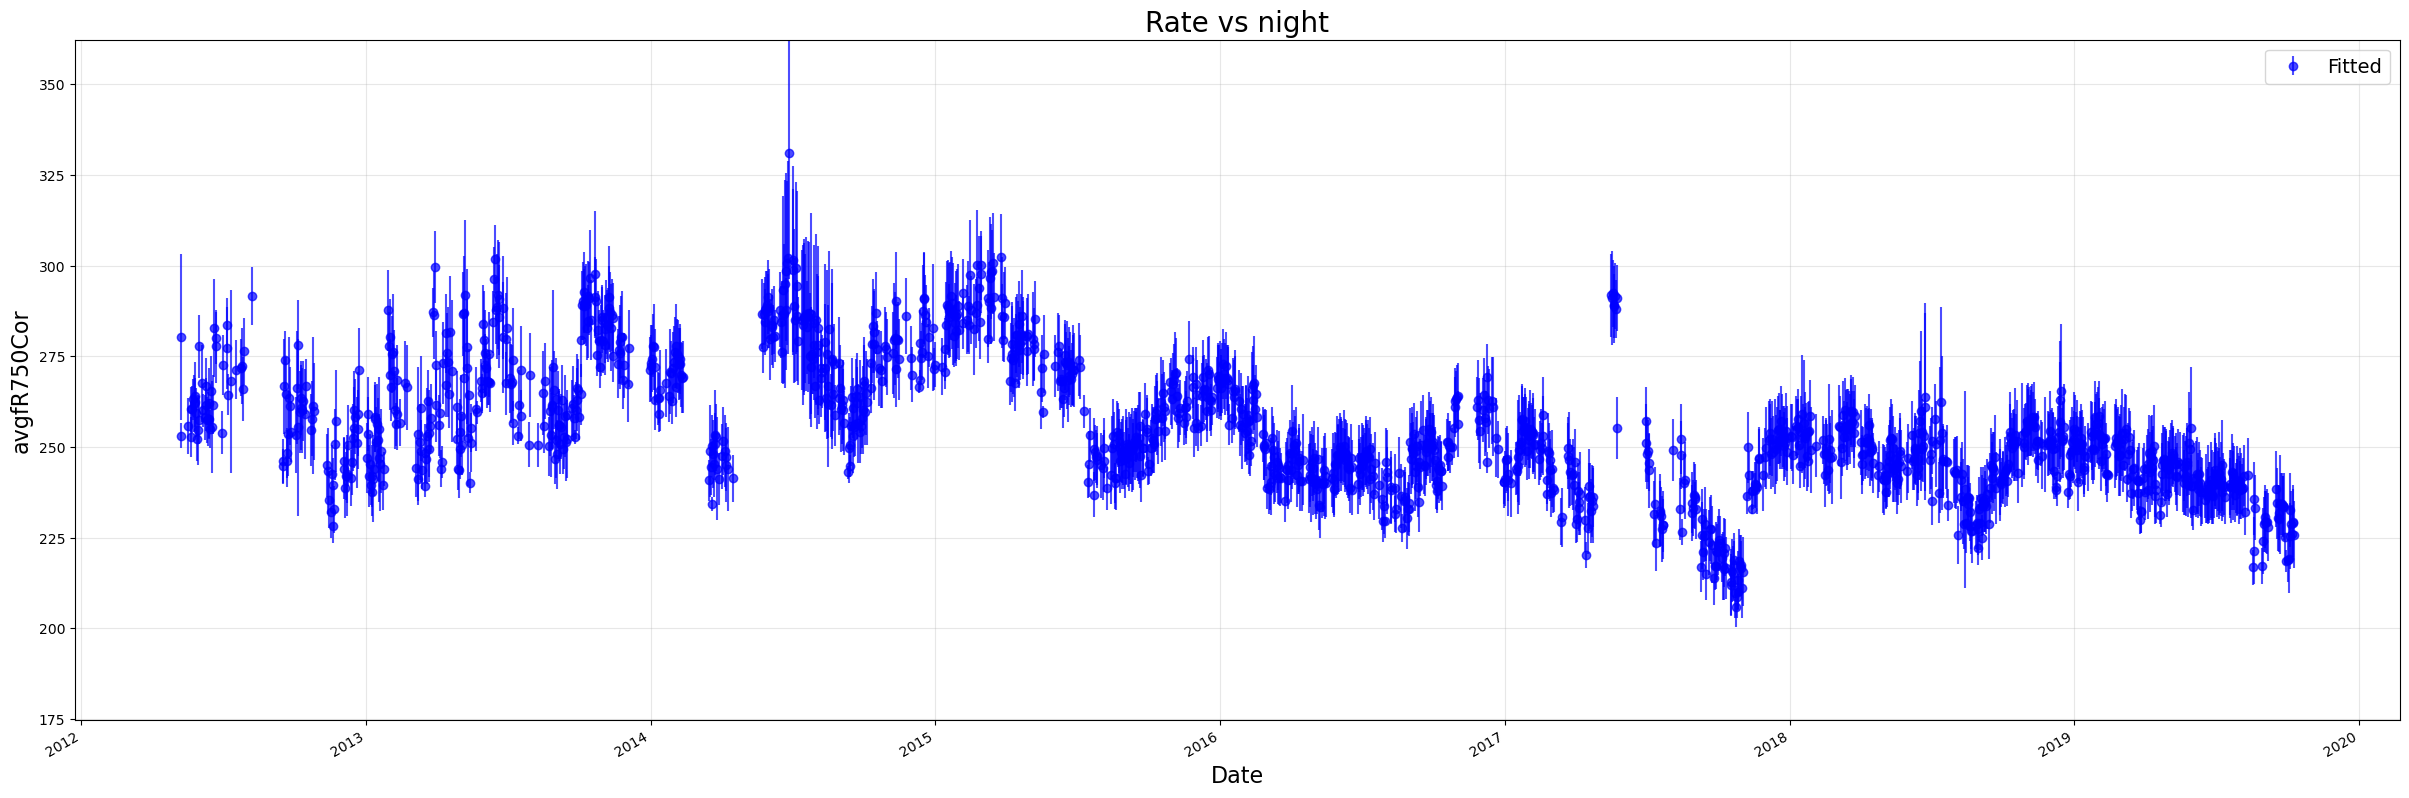

In [76]:
import matplotlib.pyplot as plt
import pandas as pd

# make a large figure with one subplot
fig, ax = plt.subplots(figsize=(30, 10))

# scatter plot with error bars
ax.errorbar(pd.to_datetime(df['ds']), df['y'], yerr=df['err_y'], 
            fmt='o', label="Fitted", color="blue", alpha=0.7)

# labels, title, legend, grid
ax.set_xlabel("Date", fontsize=16)
ax.set_ylabel("avgfR750Cor", fontsize=16)
ax.set_title("Rate vs night", fontsize=20)
ax.legend(fontsize=14)
ax.grid(True, alpha=0.3)

# format x-axis ticks
fig.autofmt_xdate()

# dynamically set limits with buffer
x_buffer = (df['ds'].max() - df['ds'].min()) * 0.05  # 5% of range
y_buffer = (df['y'].max() - df['y'].min()) * 0.25     # 10% of range

ax.set_xlim(df['ds'].min() - x_buffer, df['ds'].max() + x_buffer)
ax.set_ylim(df['y'].min() - y_buffer, df['y'].max() + y_buffer)

plt.show()


## These 4 events which are close in time to one another

First show the whole time series, then zoom in 

| ID | Date | Type | Change | Comments | Influence on rate | Keep? |
|---|---|---|---|---|---|---|
| 67 | 2.3.2017 | HW | misaligned mirror found (unclear since when it was misaligned) | s fact-online - unclear until when mirror was loose | there might be a small negative step or slope somewhen in winter | TBH unsure |
| 73 | 16.-25.5.2017 | HW | too high rates, gain inhomogeneity | https://www.fact-project.org/logbook/showthread.php?tid=5163&pid=24870#pid24870 https://www.fact-project.org/logbook/showthread.php?tid=5165 | probably effect but unclear how | No, but dig deeper |
| 74 | 25.5.2017 | HW | feedback restarted with new offsets | https://www.fact-project.org/logbook/showthread.php?tid=5182&pid=24923#pid24923 (issues with high rates before that? gain inhomogeneity) | probably effect but unclear how | No, but dig deeper |
| 75 | 4.7.2017 | HW | container temperature changed to 22 deg | https://www.fact-project.org/logbook/showthread.php?tid=5288 in the context of some maintenance (data taking resumed 11.7.) (what was temperature before?? and was later on back? ) | probably effect but unclear how (might be until 27.7.) | No, but dig deeper |
| 76 | 27.7.2017 | HW | gapd-offsets updated | https://www.fact-project.org/logbook/showthread.php?tid=5341 (probably to account for change in container temperature | probably calibration for change on 4.7 | No, but dig deeper |

My gut feeling tells me we should either flag this whole period as a holiday, or straight up drop it, the single data point jump is fairly noticeable even in the long term, and the fixes seem too close to one another. Tradeoff is losing like 2 months of questionable data.


As for the winter one, i do see the small slope, but im not sure if an adjustment is needed/justified. 

## Drop data per Daniela's suggestion
Grab from september 2013 onwards

In [80]:
# clean code, docstrings, in english

# Define the start date for the training data
start_date_filter = pd.to_datetime('2013-09-01')

# Filter the main dataframe
df = df[df['ds'] > start_date_filter]

# **Apply the same filter to the event dataframes**
dust_events_df = dust_events_df[dust_events_df['start_date'] > start_date_filter]
mirror_events_df = mirror_events_df[mirror_events_df['start_date'] > start_date_filter]


# 1. Create the holidays dataframe for TNGDust events
dust_events_df['upper_window'] = (dust_events_df['end_date'] - dust_events_df['start_date']).dt.days + 1 - 1
holidays = pd.DataFrame({
    'holiday': 'TNGDust',
    'ds': dust_events_df['start_date'],
    'lower_window': 0,
    'upper_window': dust_events_df['upper_window'],
})

# 2. Create the changepoints list from the filtered mirror alignment events
changepoints = mirror_events_df['start_date'].tolist()

print(f"Filtered to start after {start_date_filter.date()}.")
print(f"Created {len(holidays)} holiday events (dust).")
print(f"Created {len(changepoints)} changepoint events (mirror alignment).")

Filtered to start after 2013-09-01.
Created 23 holiday events (dust).
Created 6 changepoint events (mirror alignment).


In [83]:
df

,ds,y,err_y
236,2013-09-02,263.085259,11.387642
237,2013-09-03,247.959058,9.462790
238,2013-09-04,260.299707,10.682064
239,2013-09-05,256.126021,9.933507
240,2013-09-06,256.055472,9.484625
...,...,...,...
1611,2019-10-06,228.672222,9.274353
1612,2019-10-07,226.110355,7.751010
1613,2019-10-08,229.159018,10.413196
1614,2019-10-09,228.963171,9.433372


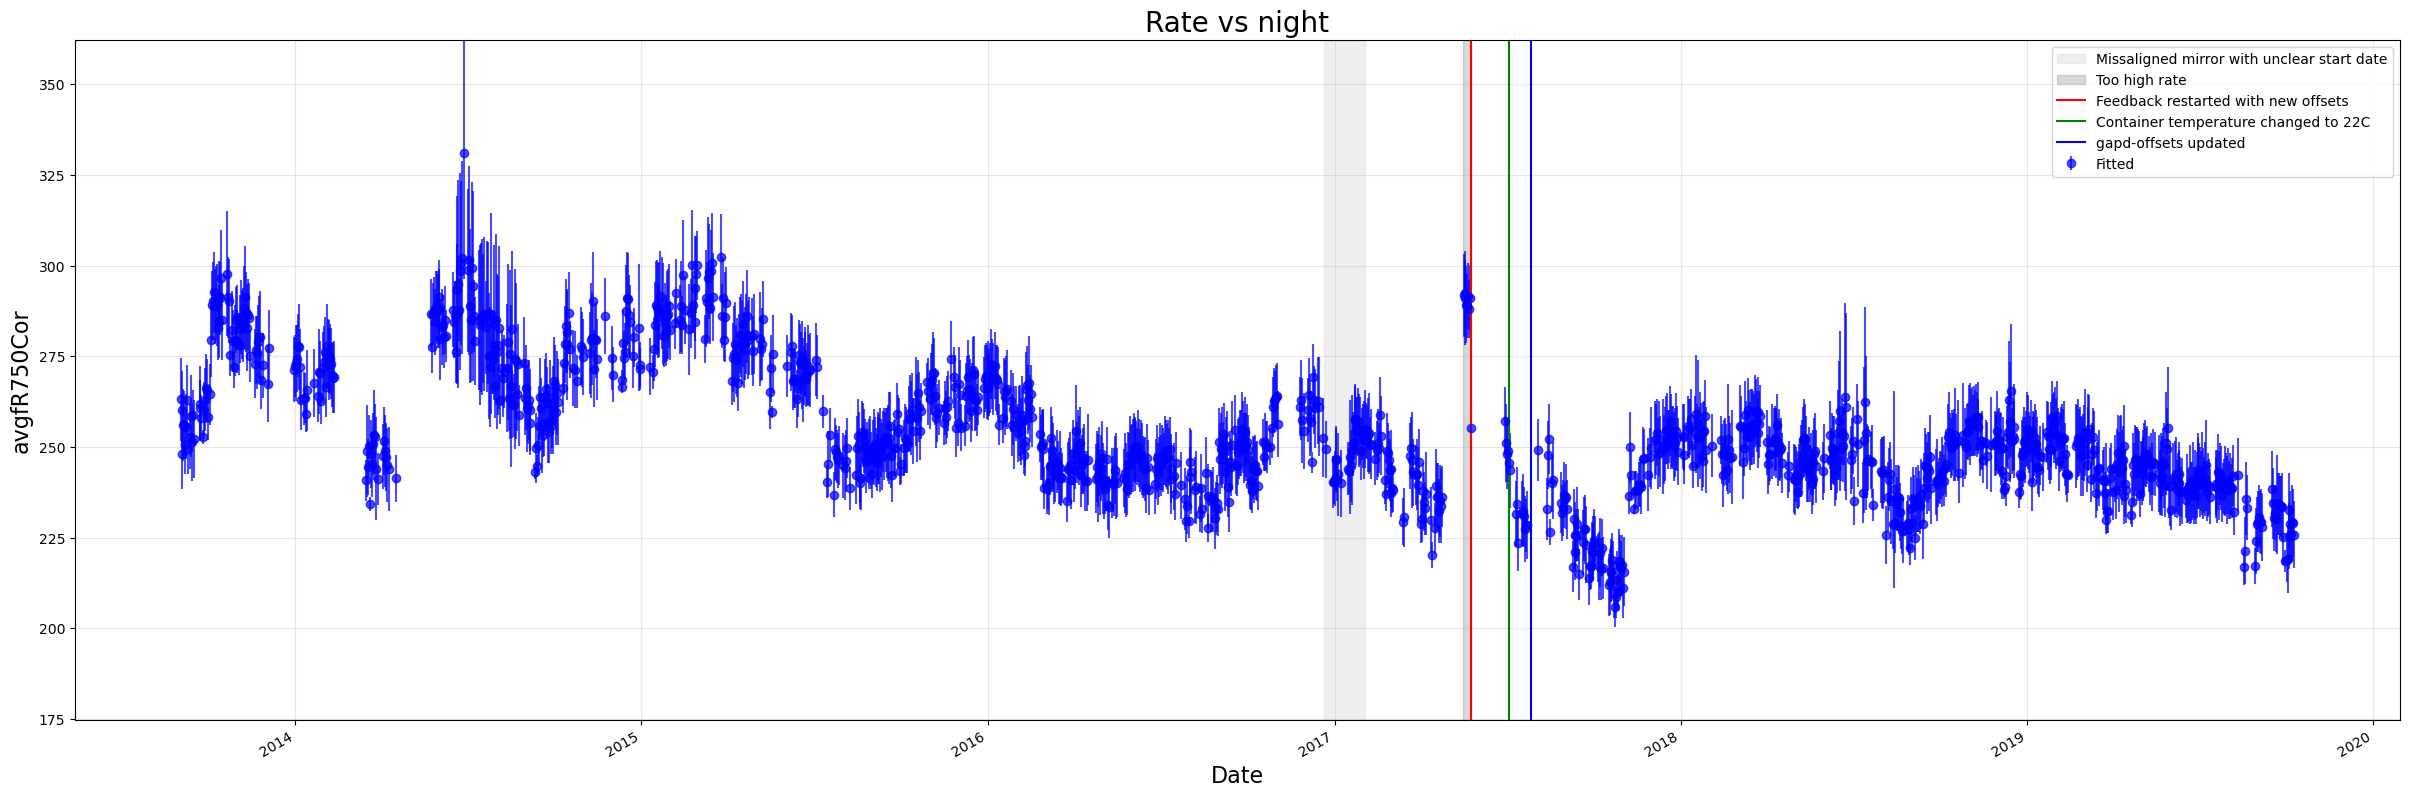

In [85]:
import matplotlib.pyplot as plt
import pandas as pd

# make a large figure with one subplot
fig, ax = plt.subplots(figsize=(30, 10))

# scatter plot with error bars
ax.errorbar(pd.to_datetime(df['ds']), df['y'], yerr=df['err_y'], 
            fmt='o', label="Fitted", color="blue", alpha=0.7)

# labels, title, legend, grid
ax.set_xlabel("Date", fontsize=16)
ax.set_ylabel("avgfR750Cor", fontsize=16)
ax.set_title("Rate vs night", fontsize=20)
ax.legend(fontsize=14)
ax.grid(True, alpha=0.3)

# format x-axis ticks
fig.autofmt_xdate()

# dynamically set limits with buffer
x_buffer = (df['ds'].max() - df['ds'].min()) * 0.05  # 5% of range
y_buffer = (df['y'].max() - df['y'].min()) * 0.25     # 10% of range

ax.set_xlim(df['ds'].min() - x_buffer, df['ds'].max() + x_buffer)
ax.set_ylim(df['y'].min() - y_buffer, df['y'].max() + y_buffer)


## Winter rate drop 


start_date = pd.to_datetime('2016-12-21') # Asumiendo "inicio de invierno"
end_date = pd.to_datetime('2017-02-02')

# 2. Dibuja el rectángulo (span) ANTES del scatter plot
ax.axvspan(start_date, end_date, 
           color='0.8',      
           alpha=0.3,         
           label='Missaligned mirror with unclear start date') # Etiqueta para la leyenda



## Too high flux range 
start_date = pd.to_datetime('2017-05-16') 
end_date = pd.to_datetime('2017-05-25')

ax.axvspan(start_date, end_date, 
           color='grey',      
           alpha=0.3,         
           label='Too high rate') # Etiqueta para la leyenda

## Feedback reset point

ax.axvline(pd.to_datetime('2017-05-25'),label='Feedback restarted with new offsets',color='r')


## Container temperature 

ax.axvline(pd.to_datetime('2017-07-04'),label='Container temperature changed to 22C',color='g')




## GAPD offsets  

ax.axvline(pd.to_datetime('2017-07-27'),label='gapd-offsets updated',color='b')




ax.legend()
plt.show()


## Drop problematic data per hypothesis 

In [87]:
start_date = '2017-05-16'
end_date = '2017-07-04'

# Create a mask for rows *outside* the range
# (Keep rows Before the start OR After the end)
mask = (df['ds'] < start_date) | (df['ds'] > end_date)

# Apply the mask
df = df[mask]

In [88]:
mirror_events_df

,type,change,comments,influence on rate,keep,start_date,end_date
0,HW,Mirror-Alignment,https://www.fact-project.org/logbook/showthre...,positive step,Yes (mirror),2014-05-10,2014-05-19
14,HW,mirror alignment eSCCAN method,somewhen between 21. and 28.5. https://www.fa...,positive step if there was a mirror alignment...,Yes (mirror),2015-05-01,2015-05-31
29,HW,mirror re-aligned,https://www.fact-project.org/logbook/showthre...,small positive step (mostly 2 mirrors aligned...,Yes (mirror),2016-09-01,2016-09-01
36,HW,misaligned mirror taken off,s fact-online,negative step (1/30),Yes (mirror),2017-03-03,2017-03-03
38,HW,put mirror back,https://www.fact-project.org/logbook/showthre...,some positive step,Yes (mirror),2017-04-03,2017-04-03
39,HW,aligned mirror,https://www.fact-project.org/logbook/showthre...,rest of positive step expected,Yes (mirror),2017-04-07,2017-04-07


In [92]:
df

,ds,y,err_y
236,2013-09-02,263.085259,11.387642
237,2013-09-03,247.959058,9.462790
238,2013-09-04,260.299707,10.682064
239,2013-09-05,256.126021,9.933507
240,2013-09-06,256.055472,9.484625
...,...,...,...
1611,2019-10-06,228.672222,9.274353
1612,2019-10-07,226.110355,7.751010
1613,2019-10-08,229.159018,10.413196
1614,2019-10-09,228.963171,9.433372


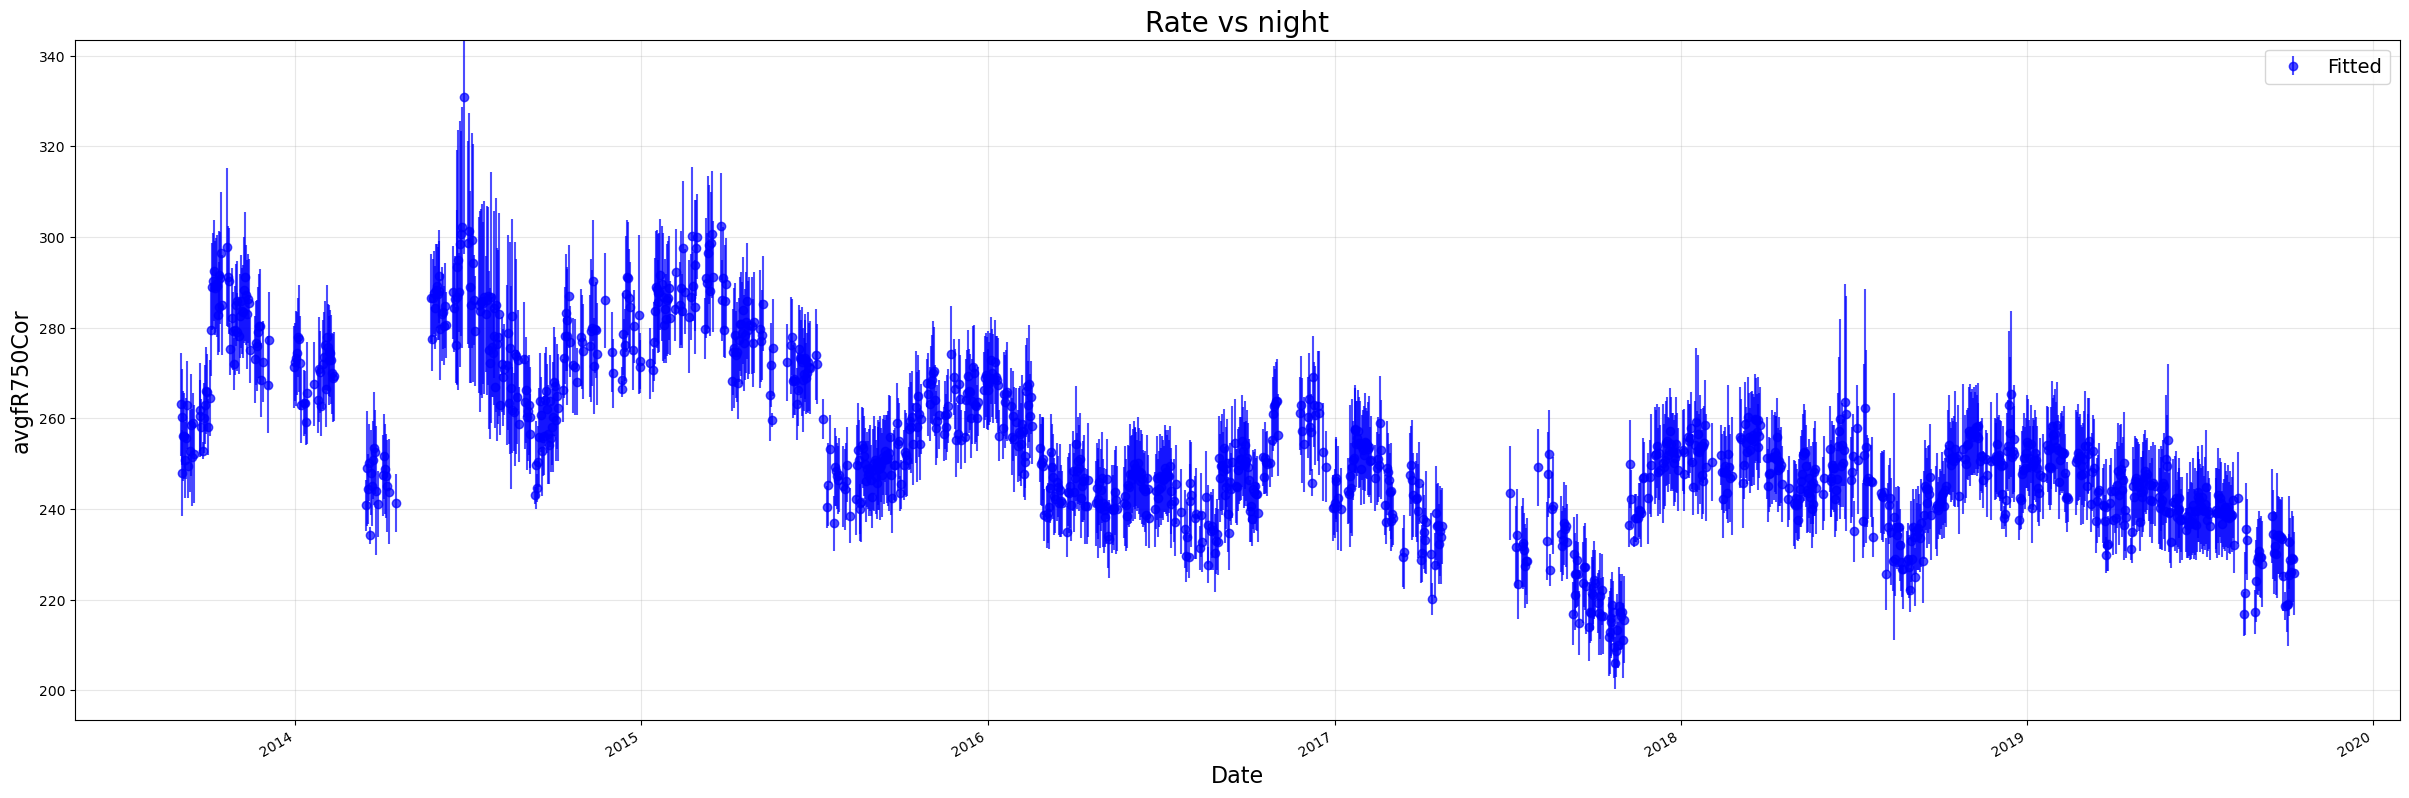

In [94]:
import matplotlib.pyplot as plt
import pandas as pd

# make a large figure with one subplot
fig, ax = plt.subplots(figsize=(30, 10))

# scatter plot with error bars
ax.errorbar(pd.to_datetime(df['ds']), df['y'], yerr=df['err_y'], 
            fmt='o', label="Fitted", color="blue", alpha=0.7)

# labels, title, legend, grid
ax.set_xlabel("Date", fontsize=16)
ax.set_ylabel("avgfR750Cor", fontsize=16)
ax.set_title("Rate vs night", fontsize=20)
ax.legend(fontsize=14)
ax.grid(True, alpha=0.3)

# format x-axis ticks
fig.autofmt_xdate()

# dynamically set limits with buffer
x_buffer = (df['ds'].max() - df['ds'].min()) * 0.05  # 5% of range
y_buffer = (df['y'].max() - df['y'].min()) * 0.1     # 10% of range

ax.set_xlim(df['ds'].min() - x_buffer, df['ds'].max() + x_buffer)
ax.set_ylim(df['y'].min() - y_buffer, df['y'].max() + y_buffer)

plt.show()


In [95]:
df['y'] = df['y']#.diff()
df = df.drop('err_y',axis=1)
df = df.dropna()
df

C:\Users\ezgva\AppData\Local\Temp\ipykernel_51428\3573746731.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['y'] = df['y']#.diff()


,ds,y
236,2013-09-02,263.085259
237,2013-09-03,247.959058
238,2013-09-04,260.299707
239,2013-09-05,256.126021
240,2013-09-06,256.055472
...,...,...
1611,2019-10-06,228.672222
1612,2019-10-07,226.110355
1613,2019-10-08,229.159018
1614,2019-10-09,228.963171


In [96]:
changepoints

[Timestamp('2014-05-10 00:00:00'),
 Timestamp('2015-05-01 00:00:00'),
 Timestamp('2016-09-01 00:00:00'),
 Timestamp('2017-03-03 00:00:00'),
 Timestamp('2017-04-03 00:00:00'),
 Timestamp('2017-04-07 00:00:00')]

In [99]:
changepoints

[Timestamp('2014-05-10 00:00:00'),
 Timestamp('2015-05-01 00:00:00'),
 Timestamp('2016-09-01 00:00:00'),
 Timestamp('2017-03-03 00:00:00'),
 Timestamp('2017-04-03 00:00:00'),
 Timestamp('2017-04-07 00:00:00')]

## Prophet implementation

In [103]:
df

,ds,y
236,2013-09-02,263.085259
237,2013-09-03,247.959058
238,2013-09-04,260.299707
239,2013-09-05,256.126021
240,2013-09-06,256.055472
...,...,...
1611,2019-10-06,228.672222
1612,2019-10-07,226.110355
1613,2019-10-08,229.159018
1614,2019-10-09,228.963171


In [105]:
import pandas as pd
import numpy as np
from scipy.signal import lombscargle

def find_dominant_period_robust(
    df: pd.DataFrame, 
    time_col: str = 'ds', 
    value_col: str = 'y',
    min_period: float = 2.0,  # Mínimo periodo a buscar (ej. 2 días)
    max_period: float = None  # Máximo periodo (si es None, usa 1/2 del total)
) -> float:
    
    # 1. PREPARACIÓN DEL TIEMPO (Crucial)
    # Convertimos fechas a "Días transcurridos" (float) preservando los huecos reales.
    df = df.copy().sort_values(time_col)
    t_start = df[time_col].min()
    
    # t será un vector como [0.0, 1.0, 2.0, 5.0, 6.0...] saltándose el 3 y 4
    t = (df[time_col] - t_start).dt.total_seconds() / (24 * 3600)
    t = t.values
    y = df[value_col].values
    
    # Centrar la señal (restar la media es necesario para análisis espectral)
    y_centered = y - np.mean(y)

    # 2. DEFINICIÓN DE FRECUENCIAS
    # Lomb-Scargle necesita que le digamos qué frecuencias probar.
    t_span = t.max() - t.min()
    
    if max_period is None:
        max_period = t_span / 1.5 # Buscar ciclos casi tan largos como los datos
        
    # Frecuencias a escanear (desde el ciclo más largo hasta el más corto)
    # Usamos oversampling (5 puntos por pico) para mayor precisión
    n_samples = len(t)
    samples_per_peak = 5
    f_min = 1 / max_period
    f_max = 1 / min_period
    
    # Resolución de la grilla de frecuencias
    df_step = 1 / (t_span * samples_per_peak)
    freqs = np.arange(f_min, f_max, df_step)
    
    # Scipy usa frecuencias angulares (w = 2*pi*f)
    angular_freqs = 2 * np.pi * freqs

    # 3. CÁLCULO DEL PERIODOGRAMA (Lomb-Scargle)
    # Pgram es la "fuerza" de la periodicidad en cada frecuencia
    pgram = lombscargle(t, y_centered, angular_freqs)

    # 4. EXTRACCIÓN DEL RESULTADO
    idx_max = np.argmax(pgram)
    best_freq = freqs[idx_max]
    dominant_period = 1 / best_freq

    return dominant_period

# --- Ejemplo de uso ---
# df = pd.read_csv('tu_archivo.csv')
# df['ds'] = pd.to_datetime(df['ds']) # Asegúrate que sea datetime
# periodo = find_dominant_period_robust(df)
# print(f"El ciclo dominante es cada {periodo:.2f} días")

In [106]:
df.ds

236    2013-09-02
237    2013-09-03
238    2013-09-04
239    2013-09-05
240    2013-09-06
          ...    
1611   2019-10-06
1612   2019-10-07
1613   2019-10-08
1614   2019-10-09
1615   2019-10-10
Name: ds, Length: 1366, dtype: datetime64[ns]

In [107]:
df

,ds,y
236,2013-09-02,263.085259
237,2013-09-03,247.959058
238,2013-09-04,260.299707
239,2013-09-05,256.126021
240,2013-09-06,256.055472
...,...,...
1611,2019-10-06,228.672222
1612,2019-10-07,226.110355
1613,2019-10-08,229.159018
1614,2019-10-09,228.963171


In [108]:
df.ds.values[-1]

numpy.datetime64('2019-10-10T00:00:00.000000000')

In [109]:
find_dominant_period_robust(df)

268.5542168674698

## First find infered changepoints 

13:17:04 - cmdstanpy - INFO - Chain [1] start processing
13:17:04 - cmdstanpy - INFO - Chain [1] done processing


Prophet automatically detected 25 changepoints.


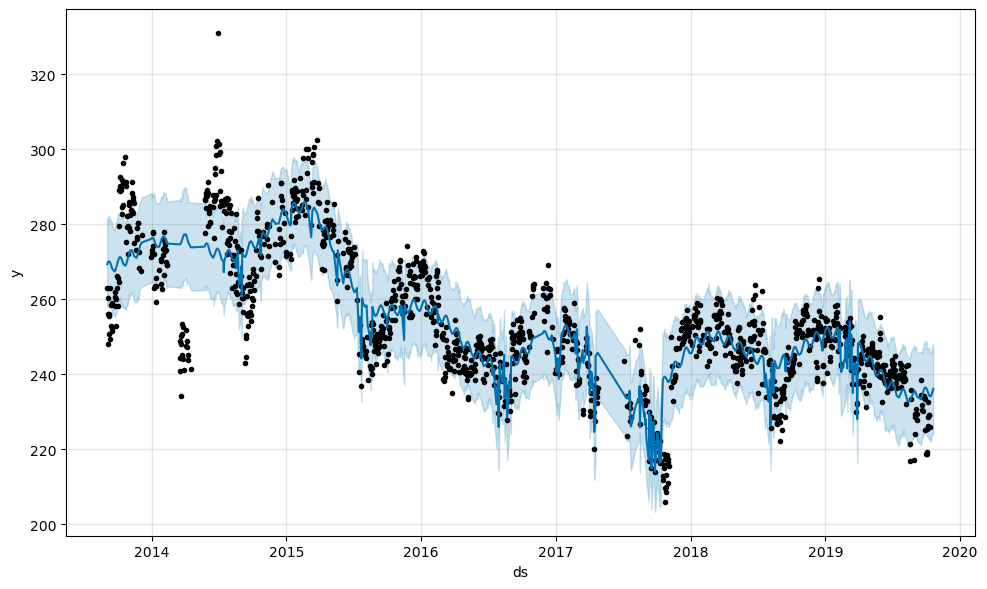

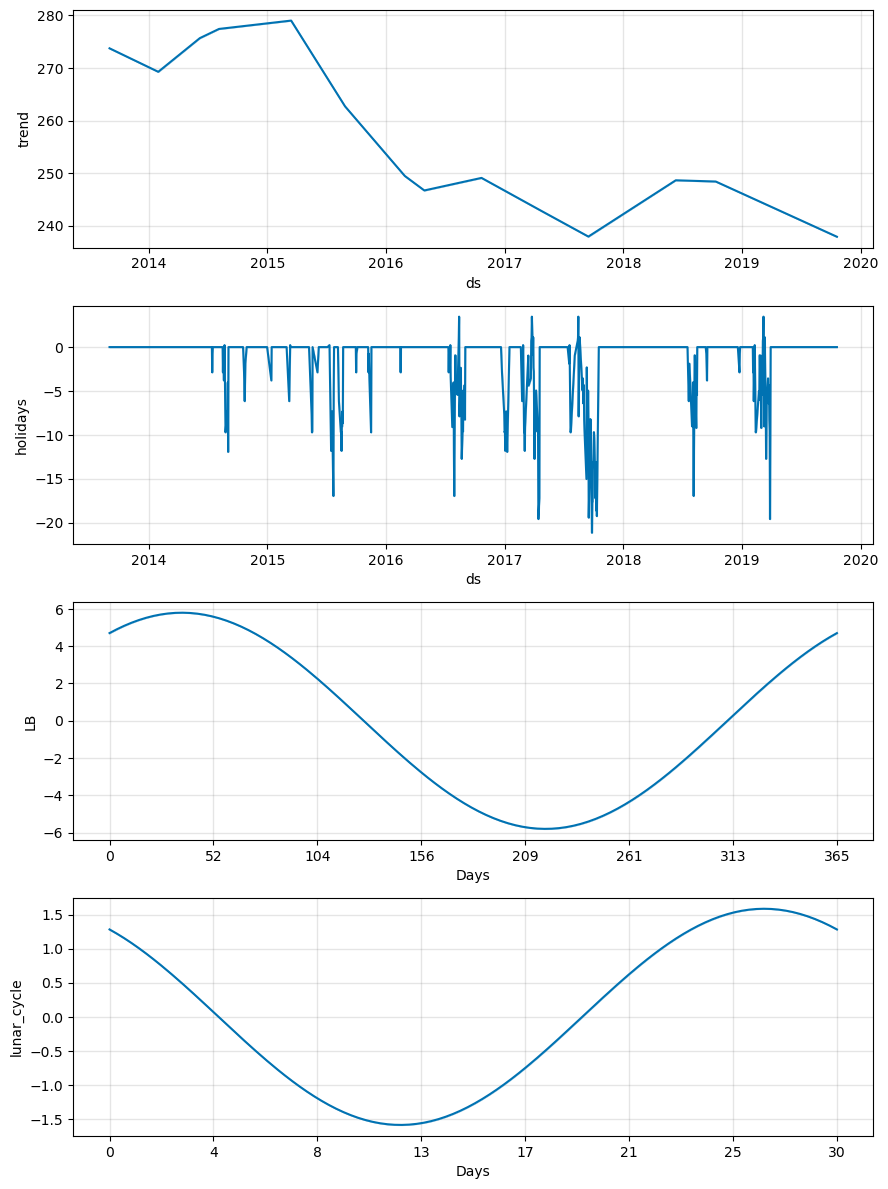

In [111]:
# clean code, docstrings, in english

# Fit a preliminary model to find automatic changepoints
# Note: We still include holidays, but NOT the changepoints argument yet.
prelim_model = Prophet(
    holidays=holidays,
    weekly_seasonality=False,
    yearly_seasonality=False
)
prelim_model.add_seasonality(name='LB', period=365, fourier_order=1)
prelim_model.add_seasonality(name='lunar_cycle', period=29.5, fourier_order=1)
prelim_model.fit(df)

# Get the changepoints detected automatically by Prophet
auto_changepoints = prelim_model.changepoints
future = prelim_model.make_future_dataframe(periods=10)
forecast = prelim_model.predict(future)
_ = prelim_model.plot(forecast)
_ = prelim_model.plot_components(forecast)
print(f"Prophet automatically detected {len(auto_changepoints)} changepoints.")

13:17:06 - cmdstanpy - INFO - Chain [1] start processing
13:17:06 - cmdstanpy - INFO - Chain [1] done processing


Prophet automatically detected 25 changepoints.


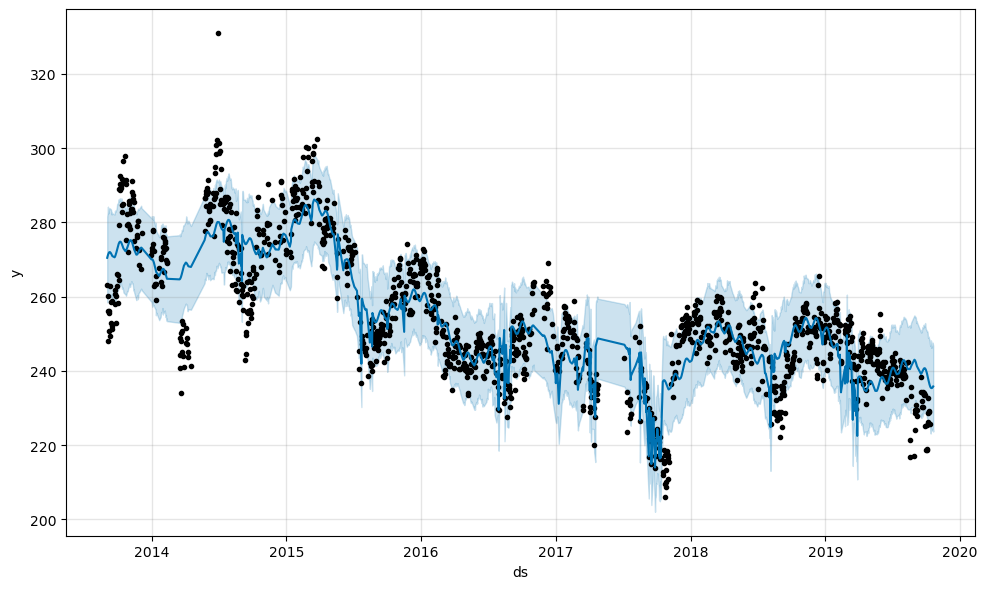

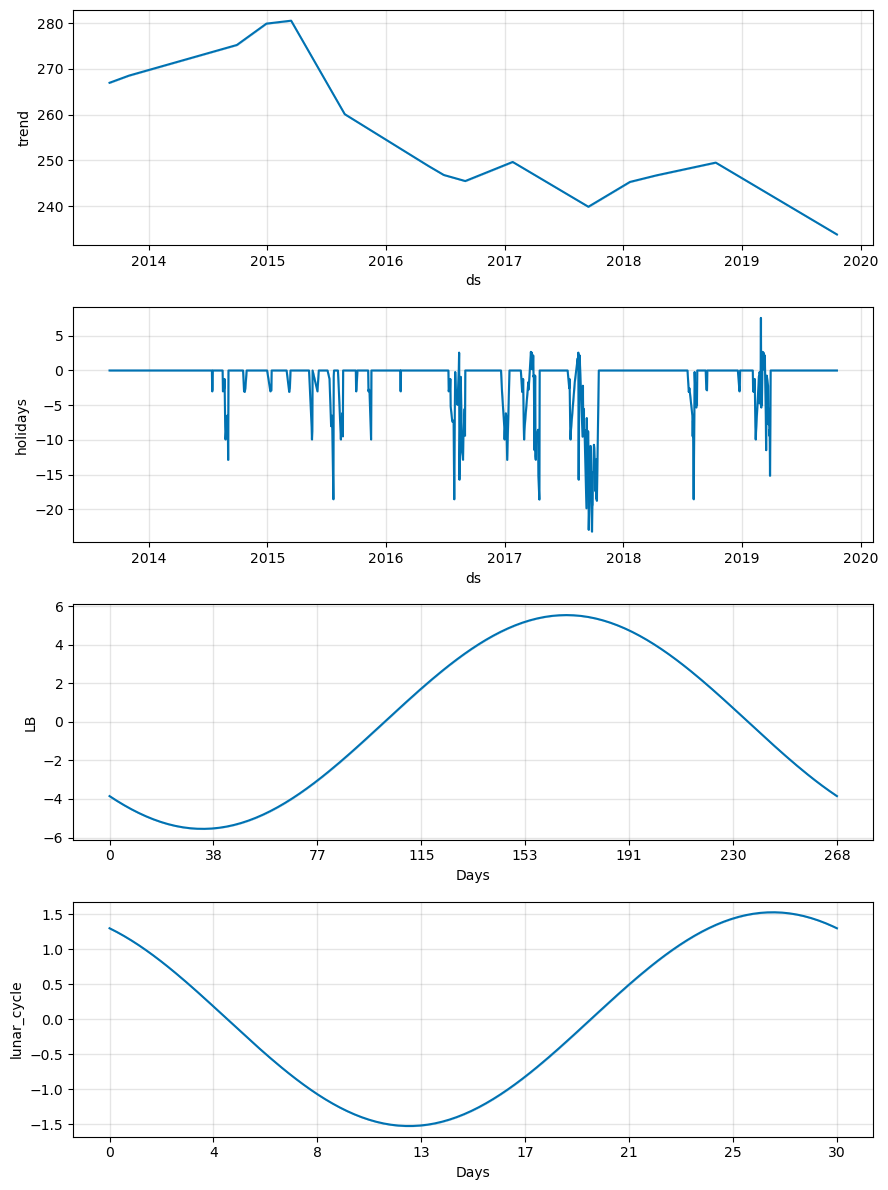

In [112]:
# clean code, docstrings, in english

# Fit a preliminary model to find automatic changepoints
# Note: We still include holidays, but NOT the changepoints argument yet.
prelim_model = Prophet(
    holidays=holidays,
    weekly_seasonality=False,
    yearly_seasonality=False
)
prelim_model.add_seasonality(name='LB', period=268, fourier_order=1)
prelim_model.add_seasonality(name='lunar_cycle', period=29.5, fourier_order=1)
prelim_model.fit(df)

# Get the changepoints detected automatically by Prophet
auto_changepoints = prelim_model.changepoints
future = prelim_model.make_future_dataframe(periods=10)
forecast = prelim_model.predict(future)
_ = prelim_model.plot(forecast)
_ = prelim_model.plot_components(forecast)
print(f"Prophet automatically detected {len(auto_changepoints)} changepoints.")

Total changepoints after combining: 30


13:17:08 - cmdstanpy - INFO - Chain [1] start processing
13:17:08 - cmdstanpy - INFO - Chain [1] done processing


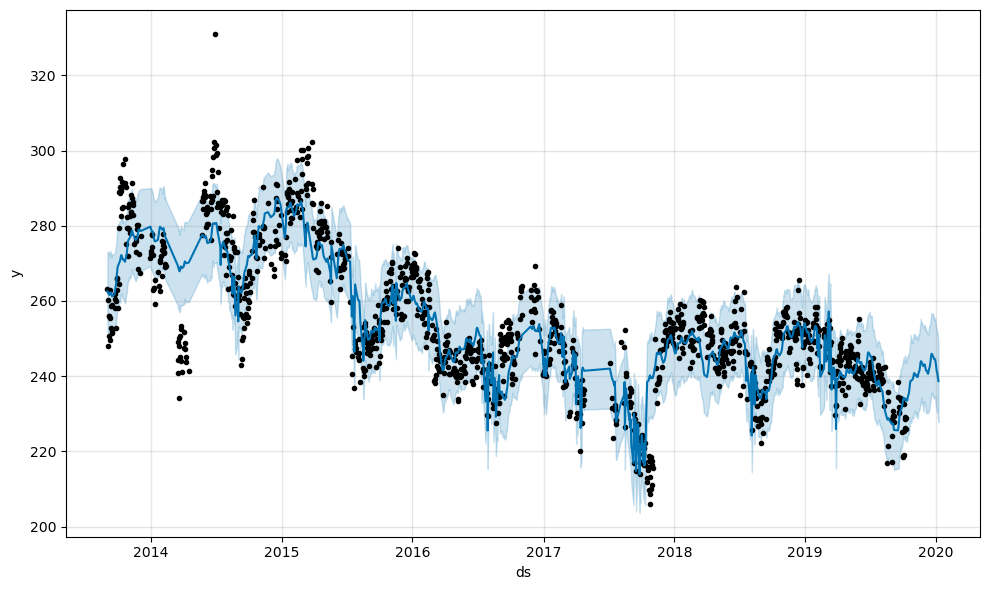

In [117]:
# clean code, docstrings, in english

# Your manual changepoints from the mirror alignment events
manual_changepoints = mirror_events_df['start_date']
# Combine the two Series of dates
combined_series = pd.concat([
    pd.to_datetime(auto_changepoints), 
    
    pd.to_datetime(manual_changepoints)
])

# **Corrected line:** Drop duplicates, sort the dates, then convert to a list
all_changepoints = combined_series.drop_duplicates().sort_values().tolist()


print(f"Total changepoints after combining: {len(all_changepoints)}")
# Now, instantiate and fit the FINAL model using the combined list
final_model = Prophet(
    holidays=holidays,
    changepoints=all_changepoints,  # Pass the combined list here
    weekly_seasonality=False,
    changepoint_prior_scale= PRIOR
)
final_model.add_seasonality(name='moon_period', period=29.5, fourier_order=5)
final_model.fit(df)

# You can now proceed with forecasting and plotting using 'final_model'
future = final_model.make_future_dataframe(periods=90)
forecast = final_model.predict(future)

fig = final_model.plot(forecast)

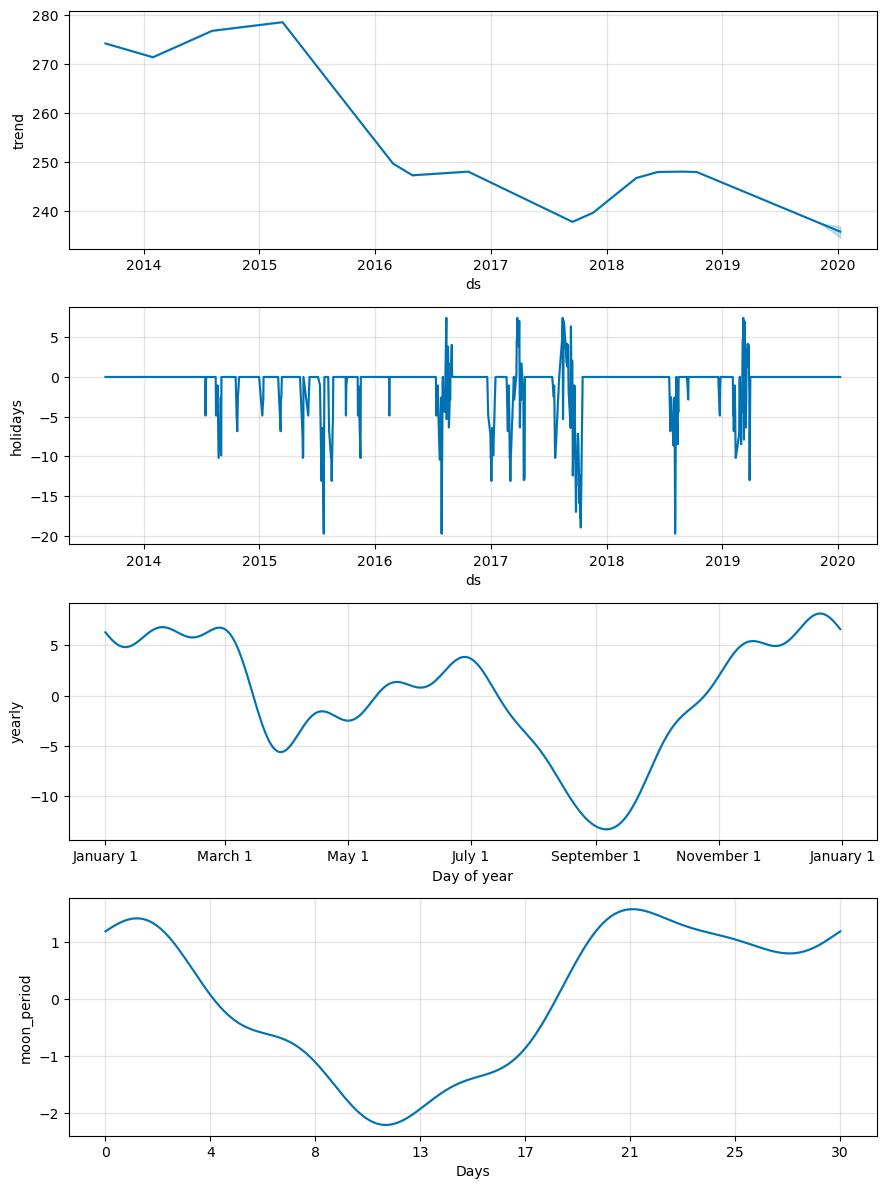

In [119]:
future = final_model.make_future_dataframe(periods=90)

forecast = final_model.predict(future)

# Plot components: trend, weekly/yearly seasonality
fig = final_model.plot_components(forecast)


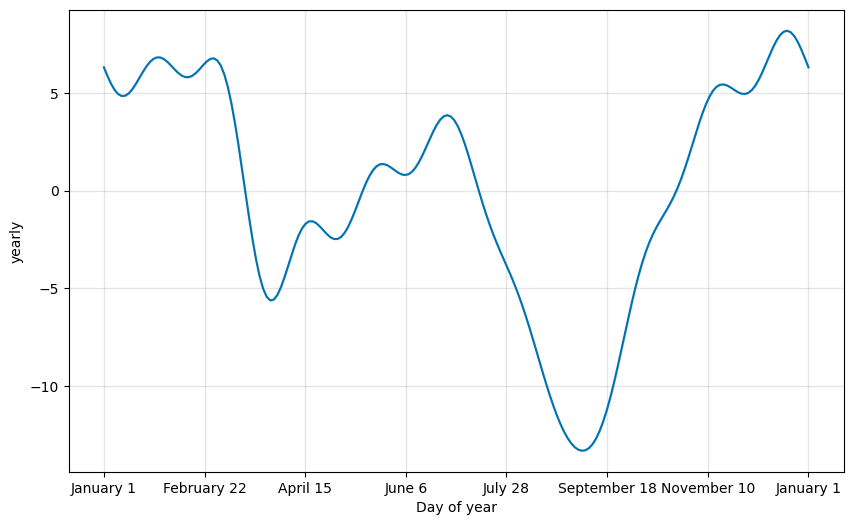

In [120]:
fig = plot_seasonality(final_model, 'yearly')


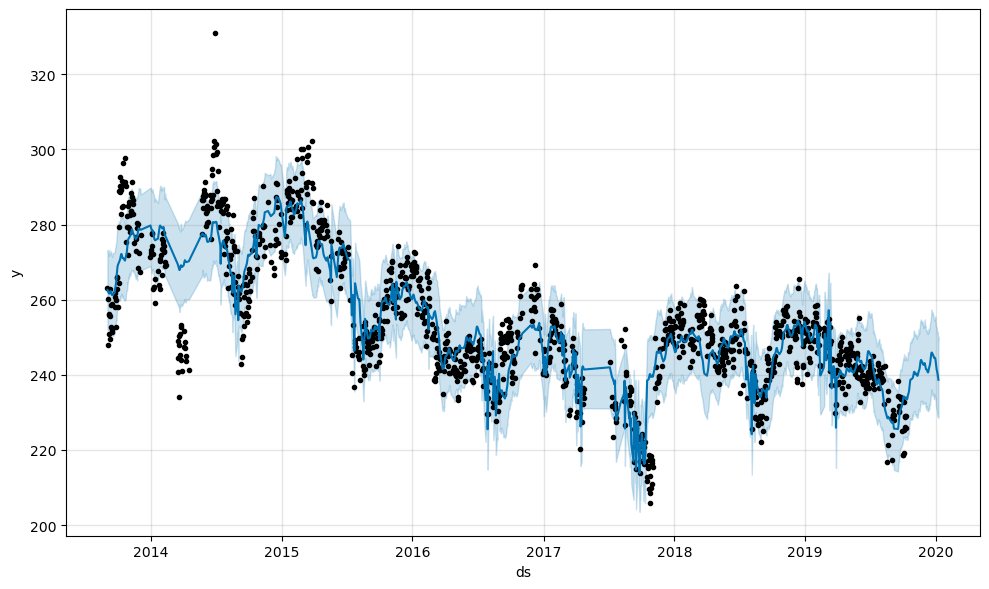

In [121]:
fig=final_model.plot(forecast)


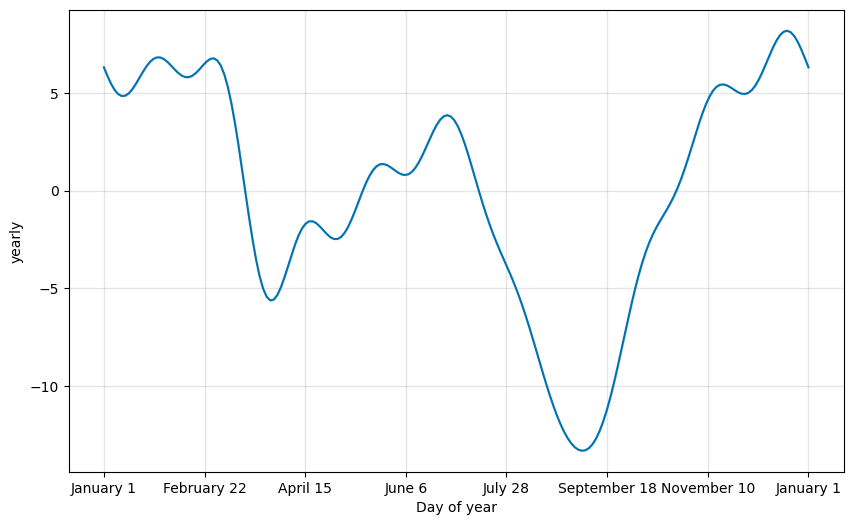

In [122]:
from prophet.plot import plot_seasonality

fig = plot_seasonality(final_model, 'yearly')
plt.show()


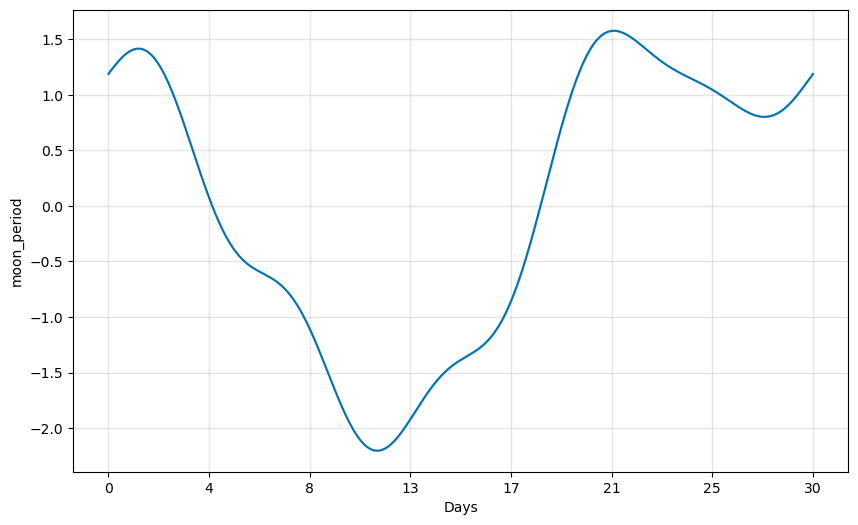

In [123]:
from prophet.plot import plot_seasonality

fig = plot_seasonality(final_model, 'moon_period')
plt.show()


In [124]:
forecast.shape

(1456, 25)

In [125]:
yhat_h = forecast.yhat[:-90].values
y = df.y.values

In [126]:
y.shape

(1366,)

In [127]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# assuming you have y (observed) and yhat_h, yhat_no_h for predictions
mae_h = mean_absolute_error(y, yhat_h)
rmse_h = np.sqrt(mean_squared_error(y, yhat_h))

#mae_no_h = mean_absolute_error(y, yhat_no_h)
#rmse_no_h = np.sqrt(mean_squared_error(y, yhat_no_h))

print("With holidays:", mae_h, rmse_h)
#print("Without holidays:", mae_no_h, rmse_no_h)


With holidays: 6.041934208278756 8.227898565804413


In [128]:
yhat_h.shape

(1366,)

In [129]:
y.shape

(1366,)

In [130]:
residuals_h = y - yhat_h
residuals_h.shape

(1366,)

In [131]:
import numpy as np

def residual_stats(residuals, name):
    print(f"{name}:")
    print(f"Mean: {np.mean(residuals):.3f}")
    print(f"Std: {np.std(residuals):.3f}")
    print(f"MAE: {np.mean(np.abs(residuals)):.3f}")
    print(f"RMSE: {np.sqrt(np.mean(residuals**2)):.3f}")
    print("------------")

residual_stats(residuals_h, "With holidays")


With holidays:
Mean: -0.000
Std: 8.228
MAE: 6.042
RMSE: 8.228
------------


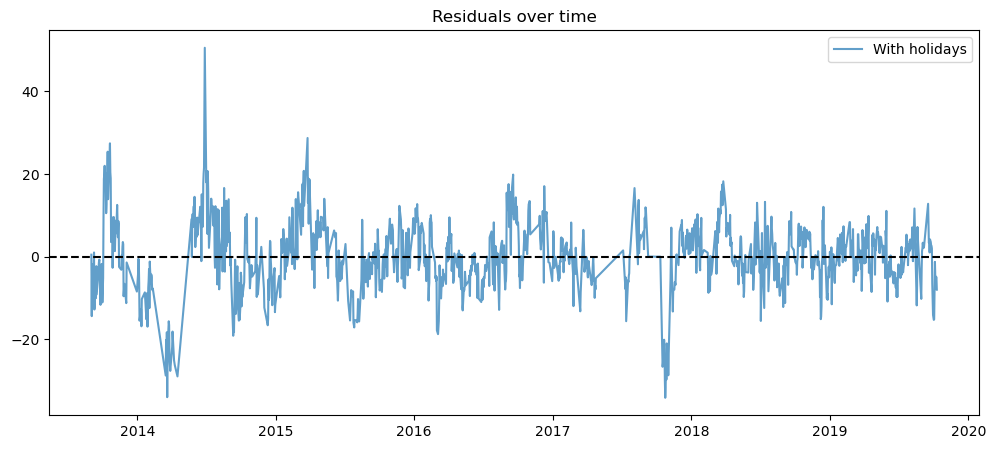

In [132]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df['ds'], residuals_h, label='With holidays', alpha=0.7)
plt.axhline(0, color='black', linestyle='--')
plt.legend()
plt.title("Residuals over time")
plt.show()


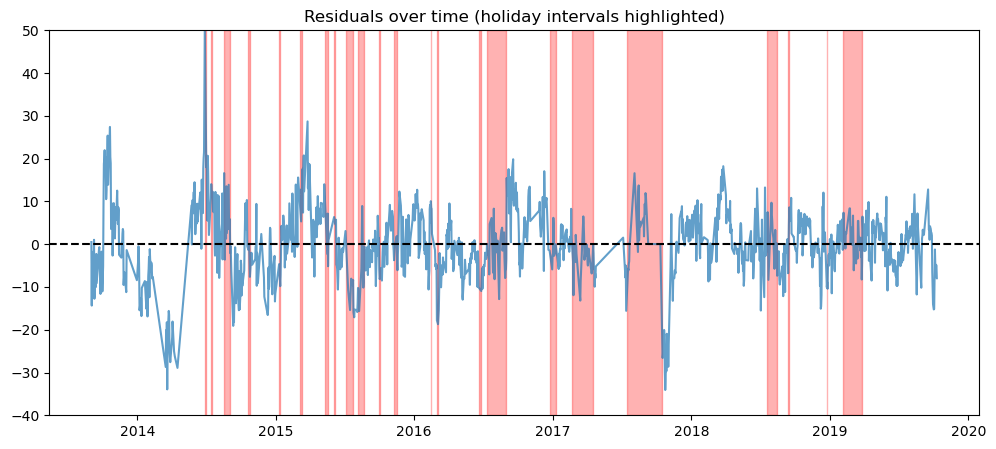

In [133]:
import matplotlib.pyplot as plt
import pandas as pd

# Example: your holidays dataframe from Prophet
# df_holidays should have columns: 'ds' (date), 'lower_window', 'upper_window'
# lower_window and upper_window are in days (can be negative for days before the holiday)
df_holidays = holidays.loc[holidays['ds']>=df['ds'].min()]  # or your holidays DataFrame

plt.figure(figsize=(12,5))
plt.plot(df['ds'], residuals_h, label='With holidays', alpha=0.7)
plt.axhline(0, color='black', linestyle='--')

# Highlight holiday intervals
for _, row in df_holidays.iterrows():
    start = row['ds'] + pd.Timedelta(days=row.get('lower_window', 0))
    end = row['ds'] + pd.Timedelta(days=row.get('upper_window', 0))
    plt.axvspan(start, end, color='red', alpha=0.3)

#plt.legend()
plt.title("Residuals over time (holiday intervals highlighted)")
plt.ylim([-40,50])
plt.show()


In [135]:
changepoints

[Timestamp('2014-05-10 00:00:00'),
 Timestamp('2015-05-01 00:00:00'),
 Timestamp('2016-09-01 00:00:00'),
 Timestamp('2017-03-03 00:00:00'),
 Timestamp('2017-04-03 00:00:00'),
 Timestamp('2017-04-07 00:00:00')]

In [136]:
holidays

,holiday,ds,lower_window,upper_window
6,TNGDust,2014-06-29,0,2
7,TNGDust,2014-07-15,0,1
8,TNGDust,2014-08-17,0,16
9,TNGDust,2014-10-21,0,5
10,TNGDust,2015-01-10,0,3
11,TNGDust,2015-03-07,0,5
12,TNGDust,2015-05-10,0,9
17,TNGDust,2015-06-04,0,2
18,TNGDust,2015-07-06,0,18
21,TNGDust,2015-08-07,0,14


Training data from 2013-09-02 to 2019-07-10
Testing data from 2019-07-11 to 2019-10-10\n


13:17:12 - cmdstanpy - INFO - Chain [1] start processing
13:17:13 - cmdstanpy - INFO - Chain [1] done processing


--- Model with Changepoints: Evaluation ---
Mean Absolute Error (MAE): 5.1921
Root Mean Squared Error (RMSE): 6.6070
-------------------------------------------


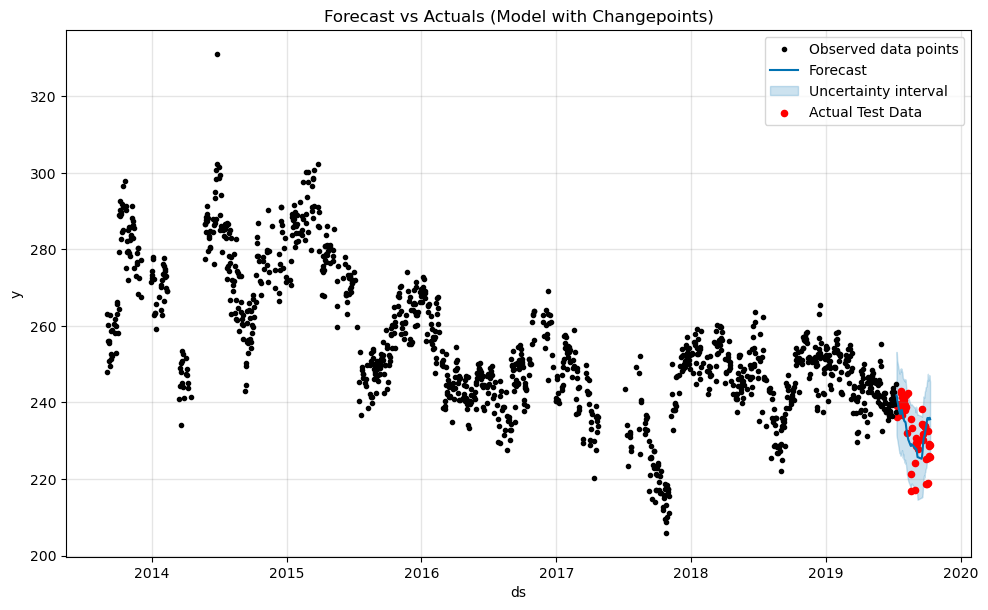

In [137]:
# clean code, docstrings, in english
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet

# 1. Define the hold-out period (last 3 months)
split_date = df['ds'].max() - pd.DateOffset(months=3)
train_df = df[df['ds'] <= split_date]
test_df = df[df['ds'] > split_date].copy() # Use .copy() to avoid SettingWithCopyWarning

print(f"Training data from {train_df['ds'].min().date()} to {train_df['ds'].max().date()}")
print(f"Testing data from {test_df['ds'].min().date()} to {test_df['ds'].max().date()}\\n")

# 2. Re-train the model on the training data ONLY
# Prophet automatically uses only the holidays and changepoints within the train_df period.
cv_model = Prophet(
    holidays=holidays,
    changepoints=all_changepoints,
    weekly_seasonality=False,
    changepoint_prior_scale= PRIOR
)
cv_model.add_seasonality(name='moon_period', period=29.5, fourier_order=5)
cv_model.fit(train_df)

# 3. Predict on the dates from the test set
# We pass a dataframe with only the 'ds' column of our test data.
forecast_cv = cv_model.predict(test_df[['ds']])

# 4. Evaluate the forecast by comparing against the actual values
mae = mean_absolute_error(test_df['y'], forecast_cv['yhat'])
rmse = np.sqrt(mean_squared_error(test_df['y'], forecast_cv['yhat']))

print("--- Model with Changepoints: Evaluation ---")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print("-------------------------------------------")


# 5. Plot the forecast against the actual test data
fig = cv_model.plot(forecast_cv)
ax = fig.gca()
ax.scatter(test_df['ds'], test_df['y'], c='r', s=20, label='Actual Test Data')
ax.set_title("Forecast vs Actuals (Model with Changepoints)")
ax.legend()
plt.show()

13:17:13 - cmdstanpy - INFO - Chain [1] start processing


Training data from 2013-09-02 to 2019-07-10
Testing data from 2019-07-11 to 2019-10-10\n


13:17:14 - cmdstanpy - INFO - Chain [1] done processing


--- Model with Changepoints: Evaluation ---
Mean Absolute Error (MAE): 5.1921
Root Mean Squared Error (RMSE): 6.6070
-------------------------------------------


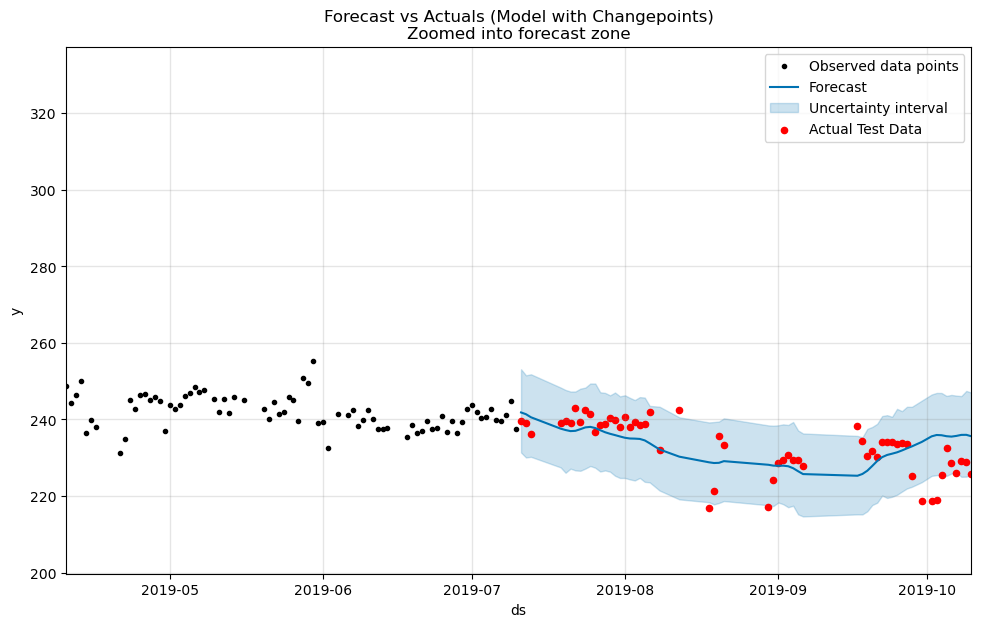

In [138]:
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet

# We assume 'df', 'holidays', 'all_changepoints', and PRIOR are already defined

# 1. Define the hold-out period (last 3 months)
split_date = df['ds'].max() - pd.DateOffset(months=3)
train_df = df[df['ds'] <= split_date]
test_df = df[df['ds'] > split_date].copy() # Use .copy() to avoid SettingWithCopyWarning

print(f"Training data from {train_df['ds'].min().date()} to {train_df['ds'].max().date()}")
print(f"Testing data from {test_df['ds'].min().date()} to {test_df['ds'].max().date()}\\n")

# 2. Re-train the model on the training data ONLY
cv_model = Prophet(
    holidays=holidays,
    changepoints=all_changepoints,
    weekly_seasonality=False,
    changepoint_prior_scale= PRIOR
)
cv_model.add_seasonality(name='moon_period', period=29.5, fourier_order=5)
cv_model.fit(train_df)

# 3. Predict on the dates from the test set
forecast_cv = cv_model.predict(test_df[['ds']])

# 4. Evaluate the forecast by comparing against the actual values
mae = mean_absolute_error(test_df['y'], forecast_cv['yhat'])
rmse = np.sqrt(mean_squared_error(test_df['y'], forecast_cv['yhat']))

print("--- Model with Changepoints: Evaluation ---")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print("-------------------------------------------")


# 5. Plot the forecast against the actual test data
fig = cv_model.plot(forecast_cv)
ax = fig.gca()
ax.scatter(test_df['ds'], test_df['y'], c='r', s=20, label='Actual Test Data')
ax.set_title("Forecast vs Actuals (Model with Changepoints)\nZoomed into forecast zone")
ax.legend()

# --- NEW: Set the x-axis limits to zoom in ---
end_of_forecast = forecast_cv['ds'].max()
start_of_zoom = end_of_forecast - pd.DateOffset(months=6)
ax.set_xlim([start_of_zoom, end_of_forecast])

plt.show()

13:17:14 - cmdstanpy - INFO - Chain [1] start processing
13:17:15 - cmdstanpy - INFO - Chain [1] done processing


--- Model WITH Changepoints: Residuals Summary ---
Average Residual (Model Bias): -0.1494
A value close to 0 indicates the model has no systematic bias (it doesn't tend to over or under-forecast).



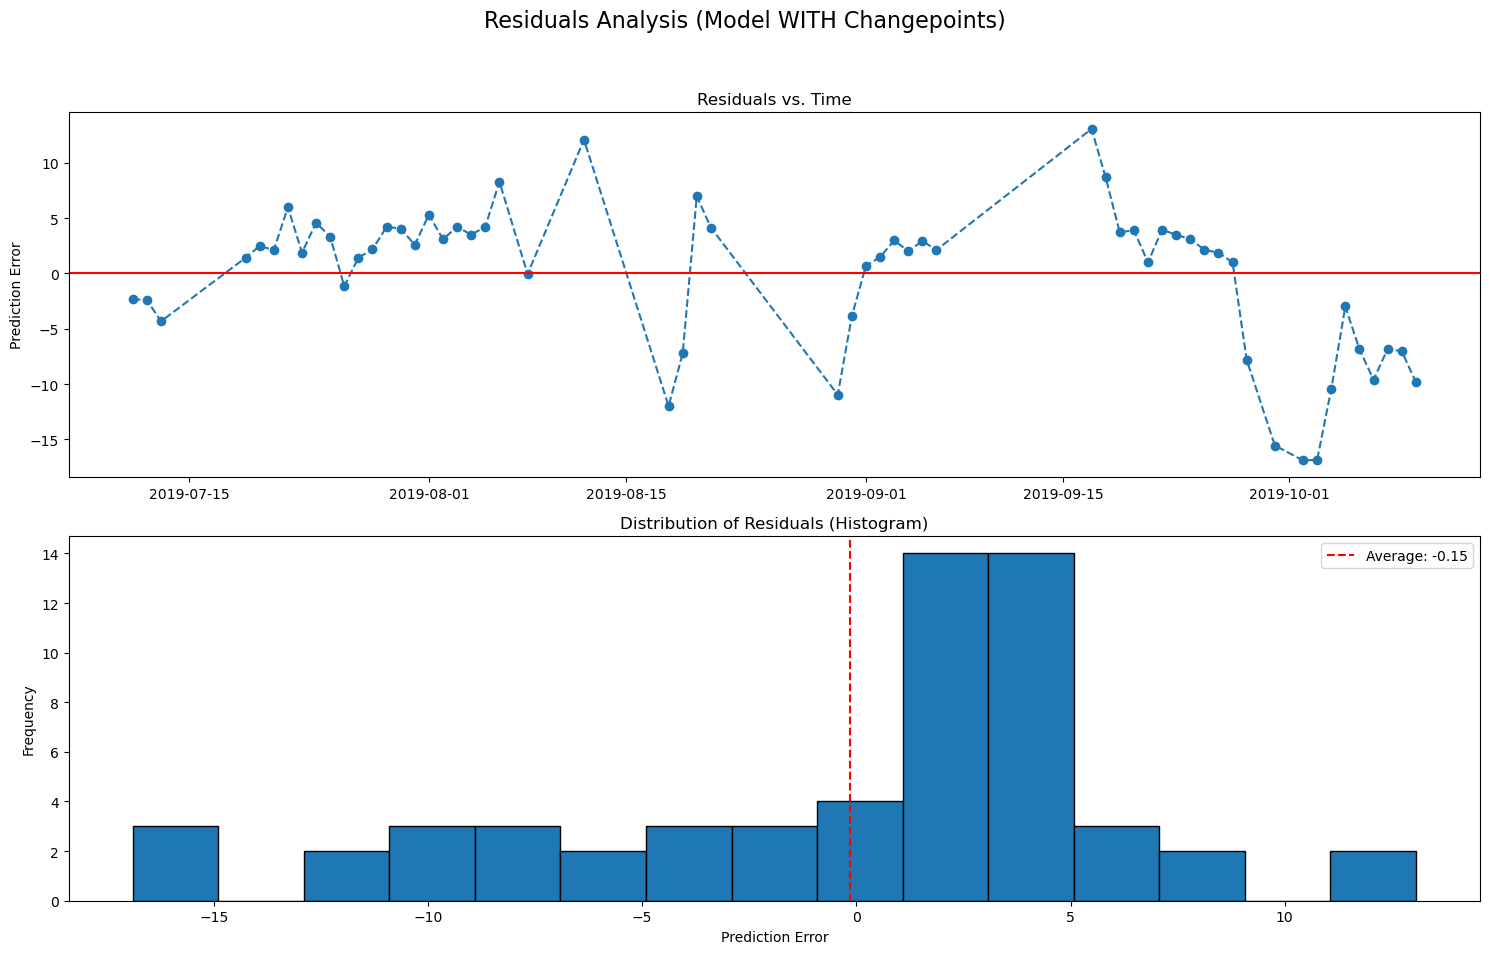

In [139]:
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
from prophet import Prophet
import matplotlib.pyplot as plt

# 1. We assume 'df', 'holidays', and 'all_changepoints' are already defined
split_date = df['ds'].max() - pd.DateOffset(months=3)
train_df = df[df['ds'] <= split_date]
test_df = df[df['ds'] > split_date].copy()

# 2. Re-train the model
cv_model = Prophet(
    holidays=holidays,
    changepoints=all_changepoints,
    weekly_seasonality=False,
    changepoint_prior_scale= PRIOR
)
cv_model.add_seasonality(name='moon_period', period=29.5, fourier_order=5)
cv_model.fit(train_df)

# 3. Predict
forecast_cv = cv_model.predict(test_df[['ds']])

# 4. Create the summary DataFrame
summary_df = pd.DataFrame({
    'ds': test_df['ds'].values,
    'y_actual': test_df['y'].values,
    'y_predicted': forecast_cv['yhat'].values
})
summary_df['residual'] = summary_df['y_actual'] - summary_df['y_predicted']

# --- NEW: Summary and Plots ---

# 5. Calculate and display the Average Residual (Bias)
average_residual = summary_df['residual'].mean()
print("--- Model WITH Changepoints: Residuals Summary ---")
print(f"Average Residual (Model Bias): {average_residual:.4f}")
print("A value close to 0 indicates the model has no systematic bias (it doesn't tend to over or under-forecast).\n")


# 6. Create Residual Plots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))
fig.suptitle('Residuals Analysis (Model WITH Changepoints)', fontsize=16)

# Plot 1: Residuals over Time
ax1.plot(summary_df['ds'], summary_df['residual'], marker='o', linestyle='--')
ax1.axhline(y=0, color='r', linestyle='-')
ax1.set_title('Residuals vs. Time')
ax1.set_ylabel('Prediction Error')

# Plot 2: Histogram of Residuals
ax2.hist(summary_df['residual'], bins=15, edgecolor='black')
ax2.axvline(x=average_residual, color='r', linestyle='--', label=f'Average: {average_residual:.2f}')
ax2.set_title('Distribution of Residuals (Histogram)')
ax2.set_xlabel('Prediction Error')
ax2.set_ylabel('Frequency')
ax2.legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

13:17:16 - cmdstanpy - INFO - Chain [1] start processing
13:17:16 - cmdstanpy - INFO - Chain [1] done processing


--- Model Metrics (Backtest Period) ---
Mean Absolute Error (MAE): 5.1921
Mean Squared Error (MSE): 43.6520
Standard Deviation of Residuals (std): 6.6630

(Extra) Average Residual (Bias): -0.1494
---------------------------------------


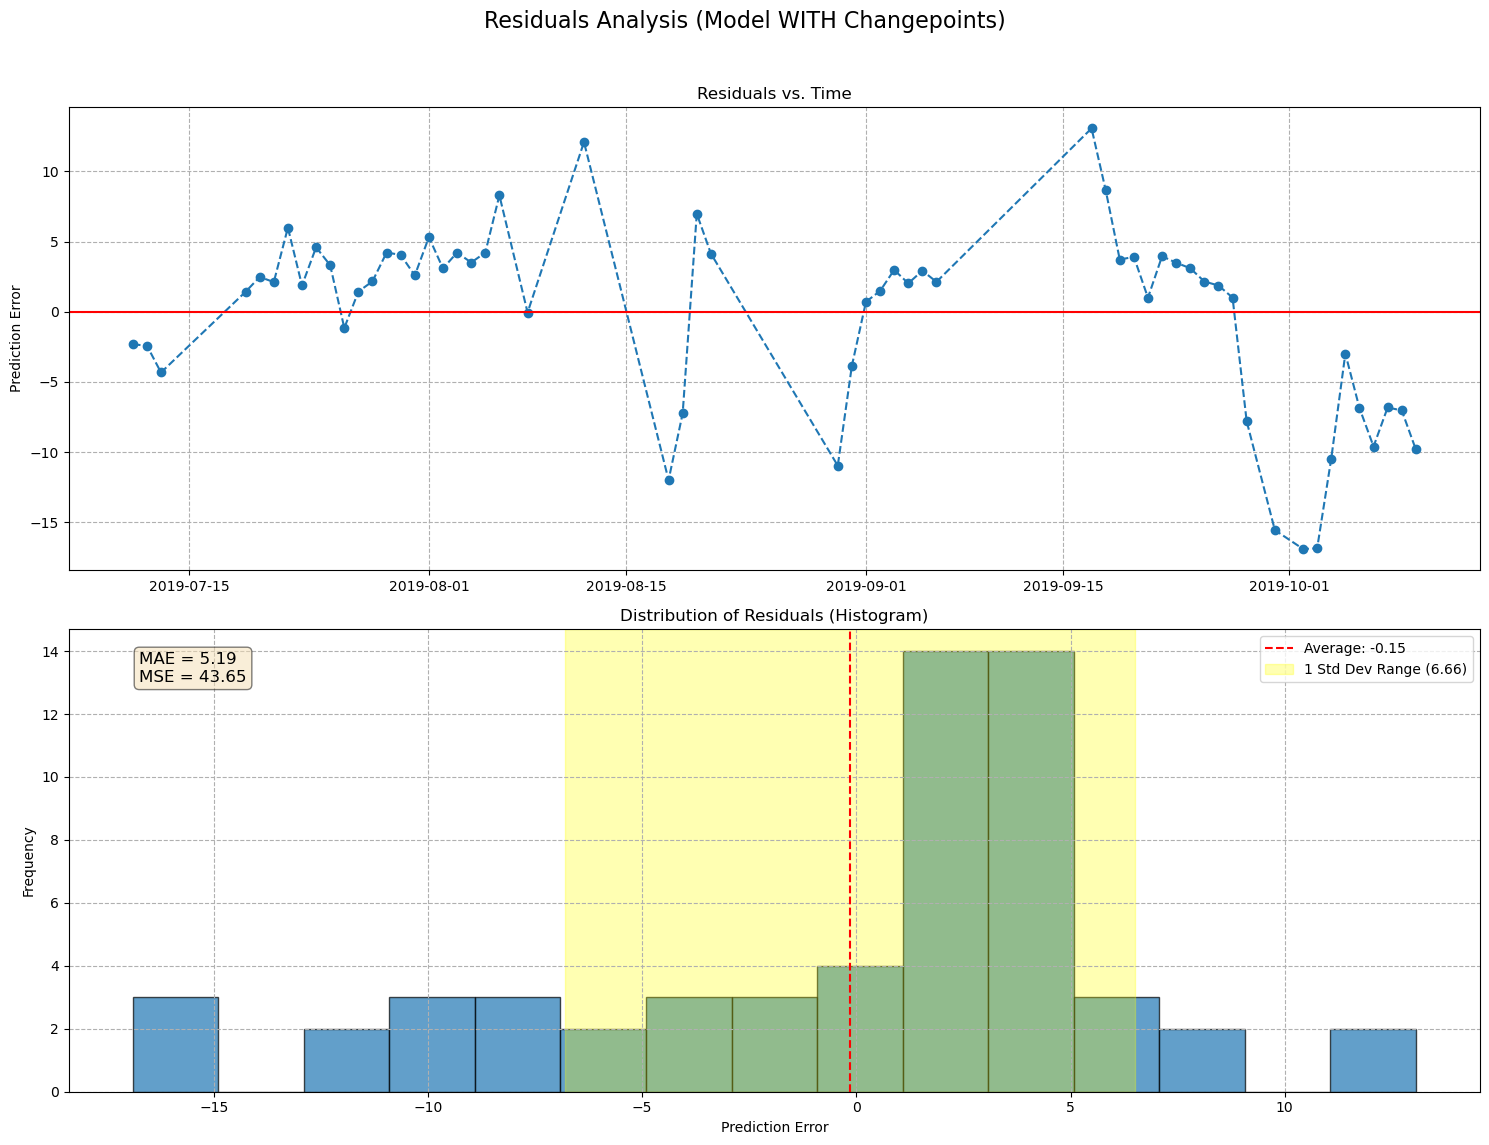

In [140]:
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
from prophet import Prophet
import matplotlib.pyplot as plt

# 1. We assume 'df', 'holidays', and 'all_changepoints' are already defined
# Also, we assume a value for PRIOR is defined
split_date = df['ds'].max() - pd.DateOffset(months=3)
train_df = df[df['ds'] <= split_date]
test_df = df[df['ds'] > split_date].copy()

# 2. Re-train the model
cv_model = Prophet(
    holidays=holidays,
    changepoints=all_changepoints,
    weekly_seasonality=False,
    changepoint_prior_scale= PRIOR
)
cv_model.add_seasonality(name='moon_period', period=29.5, fourier_order=5)
cv_model.fit(train_df)

# 3. Predict
forecast_cv = cv_model.predict(test_df[['ds']])

# 4. Create the summary DataFrame
summary_df = pd.DataFrame({
    'ds': test_df['ds'].values,
    'y_actual': test_df['y'].values,
    'y_predicted': forecast_cv['yhat'].values
})
summary_df['residual'] = summary_df['y_actual'] - summary_df['y_predicted']

# 5. Calculate metrics
mae = summary_df['residual'].abs().mean()
mse = (summary_df['residual']**2).mean()
std_resid = summary_df['residual'].std()
avg_resid = summary_df['residual'].mean()

print("--- Model Metrics (Backtest Period) ---")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Standard Deviation of Residuals (std): {std_resid:.4f}")
print(f"\n(Extra) Average Residual (Bias): {avg_resid:.4f}")
print("---------------------------------------")


# 6. Create Residual Plots with updated histogram
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12))
fig.suptitle('Residuals Analysis (Model WITH Changepoints)', fontsize=16)

# Plot 1: Residuals over Time
ax1.plot(summary_df['ds'], summary_df['residual'], marker='o', linestyle='--')
ax1.axhline(y=0, color='r', linestyle='-')
ax1.set_title('Residuals vs. Time')
ax1.set_ylabel('Prediction Error')
ax1.grid(True, linestyle='--')

# Plot 2: Histogram of Residuals with Metrics
ax2.hist(summary_df['residual'], bins=15, edgecolor='black', alpha=0.7)
ax2.set_title('Distribution of Residuals (Histogram)')
ax2.set_xlabel('Prediction Error')
ax2.set_ylabel('Frequency')

# Add average line
ax2.axvline(x=avg_resid, color='red', linestyle='--', label=f'Average: {avg_resid:.2f}')

# Shade the area for +/- 1 Standard Deviation
one_std_lower = avg_resid - std_resid
one_std_upper = avg_resid + std_resid
ax2.axvspan(one_std_lower, one_std_upper, color='yellow', alpha=0.3, label=f'1 Std Dev Range ({std_resid:.2f})')

# Add a text box for MAE and MSE metrics
textstr = '\n'.join((
    f'MAE = {mae:.2f}',
    f'MSE = {mse:.2f}'))
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
ax2.text(0.05, 0.95, textstr, transform=ax2.transAxes, fontsize=12,
        verticalalignment='top', bbox=props)

ax2.legend()
ax2.grid(True, linestyle='--')

plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()